In [ ]:
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-21.0.10"

# Inicialización de Spark con configuración de seguridad
spark = SparkSession.builder \
    .appName("Nasa_Log_Analysis") \
    .config("spark.sql.ansi.enabled", "false") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("✅ Sesión de Spark iniciada (Modo ANSI desactivado para limpieza de datos)")


✅ Sesión de Spark iniciada (Modo ANSI desactivado para limpieza de datos)


In [20]:
# Carga archivo log como txt
log_path = r"C:\Users\junio\Documents\Datacamp PySpark\Datasets\access.log"
raw_logs = spark.read.text(log_path)

# Regex Simplificado y exacto para el formato NASA
# Ejemplo: in24.inetnebr.com - - [01/Aug/1995:00:00:01 -0400] "GET /ruta HTTP/1.0" 200 1839
pattern = r'^(\S+) - - \[(.*?)\] "(.*?) (.*?) (.*?)" (\d{3}) (\d+|-)'

structured_logs = raw_logs.select(
    F.regexp_extract('value', pattern, 1).alias('ip'),
    F.regexp_extract('value', pattern, 2).alias('timestamp'),
    F.regexp_extract('value', pattern, 3).alias('method'),
    F.regexp_extract('value', pattern, 4).alias('endpoint'),
    F.regexp_extract('value', pattern, 6).cast("int").alias('status_code'),
    F.regexp_extract('value', pattern, 7).alias('content_size')
)

# Limpiar filas que no coincidieron con el Regex
structured_logs = structured_logs.filter(F.col("ip") != "")

print(f"✅ Registros procesados: {structured_logs.count():,}")
structured_logs.show(5, truncate=False)



✅ Registros procesados: 1,568,099
+-----------------+--------------------------+------+-----------------------------------------------+-----------+------------+
|ip               |timestamp                 |method|endpoint                                       |status_code|content_size|
+-----------------+--------------------------+------+-----------------------------------------------+-----------+------------+
|in24.inetnebr.com|01/Aug/1995:00:00:01 -0400|GET   |/shuttle/missions/sts-68/news/sts-68-mcc-05.txt|200        |1839        |
|uplherc.upl.com  |01/Aug/1995:00:00:07 -0400|GET   |/                                              |304        |0           |
|uplherc.upl.com  |01/Aug/1995:00:00:08 -0400|GET   |/images/ksclogo-medium.gif                     |304        |0           |
|uplherc.upl.com  |01/Aug/1995:00:00:08 -0400|GET   |/images/MOSAIC-logosmall.gif                   |304        |0           |
|uplherc.upl.com  |01/Aug/1995:00:00:08 -0400|GET   |/images/USA-logosmall.gi

🚨 TOP 5 IPs CON MÁS ERRORES (Posibles Atacantes/Bots):
+--------------------+-----+
|                  ip|count|
+--------------------+-----+
|dialip-217.den.mm...|   62|
|piweba3y.prodigy.com|   47|
|        155.148.25.4|   44|
|scooter.pa-x.dec.com|   39|
|        maz3.maz.net|   39|
+--------------------+-----+
only showing top 5 rows
📑 TOP 5 PÁGINAS MÁS VISITADAS:
+----------------------------+-----+
|endpoint                    |count|
+----------------------------+-----+
|/images/NASA-logosmall.gif  |97293|
|/images/KSC-logosmall.gif   |75283|
|/images/MOSAIC-logosmall.gif|67356|
|/images/USA-logosmall.gif   |66975|
|/images/WORLD-logosmall.gif |66351|
+----------------------------+-----+
only showing top 5 rows
⏰ TRÁFICO POR HORA DEL DÍA (Distribución de carga):
+----+------+
|hour| count|
+----+------+
|  00| 47660|
|  01| 38444|
|  02| 32481|
|  03| 29966|
|  04| 26749|
|  05| 27550|
|  06| 31258|
|  07| 47353|
|  08| 65425|
|  09| 78618|
|  10| 88238|
|  11| 95230|
|  12|1049

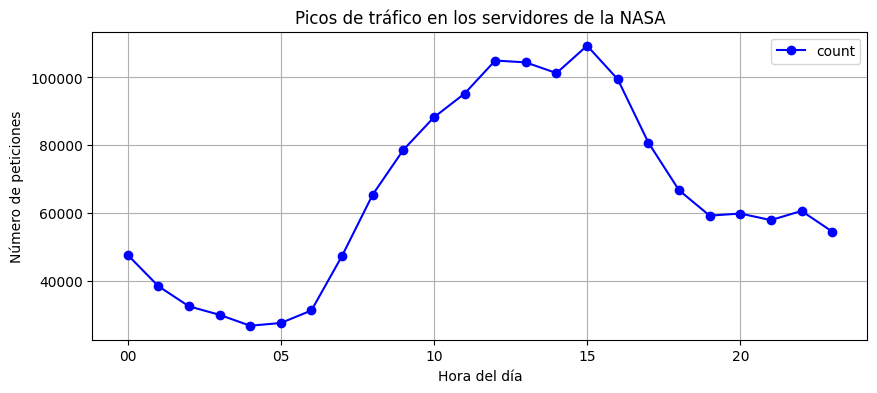

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

spark.conf.set("spark.sql.ansi.enabled", "false")

# 1. ANÁLISIS DE SEGURIDAD (Errores 4xx y 5xx)
errores_df = structured_logs.filter(F.col("status_code") >= 400) \
    .groupBy("ip").count() \
    .orderBy(F.col("count").desc())

print("🚨 TOP 5 IPs CON MÁS ERRORES (Posibles Atacantes/Bots):")
errores_df.show(5)

# 2. ANÁLISIS DE CONTENIDO
paginas_populares = structured_logs.groupBy("endpoint").count() \
    .orderBy(F.col("count").desc())

print("📑 TOP 5 PÁGINAS MÁS VISITADAS:")
paginas_populares.show(5, truncate=False)

# 3. ANÁLISIS DE TRÁFICO TEMPORAL (Por hora)
trafico_hora = structured_logs.withColumn("hour", F.substring("timestamp", 13, 2)) \
    .groupBy("hour").count() \
    .orderBy("hour")

print("⏰ TRÁFICO POR HORA DEL DÍA (Distribución de carga):")
trafico_hora.show(24)

print("\n📊 Generando gráfica de tráfico...")
df_plot = trafico_hora.toPandas()
df_plot.plot(kind='line', x='hour', y='count', marker='o', color='blue', figsize=(10,4))
plt.title("Picos de tráfico en los servidores de la NASA")
plt.xlabel("Hora del día")
plt.ylabel("Número de peticiones")
plt.grid(True)
plt.show()


In [22]:
# Guardar nuevo acces.log organizado y estructurado
print("⏳ Sobreescribiendo archivo completo...")
df_completo_pd = structured_logs.toPandas()
df_completo_pd.to_csv("nasa_logs_estructurados_FULL.csv", index=False, mode='w') 
trafico_hora.toPandas().to_csv("reporte_horas.csv", index=False, mode='w')
errores_df.toPandas().to_csv("reporte_seguridad_ips.csv", index=False, mode='w')

print("✅ Todos los archivos han sido creados o actualizados")


⏳ Sobreescribiendo archivo completo...
✅ Todos los archivos han sido creados o actualizados
